In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from typing import Optional
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Get data into dataframe
df = pd.read_csv('../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_TSO = df.copy()
df_TSO = df_TSO[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]','Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]
df_TSO = df_TSO.dropna()

In [3]:
def uniform_geographic_sample(
    df: pd.DataFrame,
    n_samples: int,
    lat_col: str = 'latitude',
    lon_col: str = 'longitude',
    n_grid_cells: int = 50,
    random_state: Optional[int] = None) -> pd.DataFrame:
    """
    Sample points from a dataset to minimize spatial density variability.
    
    Uses grid-based stratified sampling to ensure uniform geographic coverage.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with geographic coordinates
    n_samples : int
        Number of samples to draw
    lat_col : str
        Name of the latitude column
    lon_col : str
        Name of the longitude column
    n_grid_cells : int
        Number of grid cells per dimension (creates n_grid_cells x n_grid_cells grid)
    random_state : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    pd.DataFrame
        Sampled dataframe with uniform spatial distribution
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    df = df.copy()
    
    # Get coordinate bounds
    lat_min, lat_max = df[lat_col].min(), df[lat_col].max()
    lon_min, lon_max = df[lon_col].min(), df[lon_col].max()
    
    # Create grid cells
    lat_bins = np.linspace(lat_min, lat_max, n_grid_cells + 1)
    lon_bins = np.linspace(lon_min, lon_max, n_grid_cells + 1)
    
    # Assign each point to a grid cell
    df['_lat_bin'] = pd.cut(df[lat_col], bins=lat_bins, labels=False, include_lowest=True)
    df['_lon_bin'] = pd.cut(df[lon_col], bins=lon_bins, labels=False, include_lowest=True)
    df['_grid_cell'] = df['_lat_bin'].astype(str) + '_' + df['_lon_bin'].astype(str)
    
    # Count points per grid cell
    cell_counts = df['_grid_cell'].value_counts()
    occupied_cells = len(cell_counts)
    
    # Calculate target samples per cell for uniform distribution
    samples_per_cell = n_samples / occupied_cells
    
    # Strategy: Sample equally from each occupied cell for uniform coverage
    # First pass: try to take equal samples from each cell
    base_samples_per_cell = n_samples // occupied_cells
    extra_samples = n_samples % occupied_cells
    
    sampled_dfs = []
    cells_to_boost = []
    
    for i, cell_id in enumerate(cell_counts.index):
        cell_df = df[df['_grid_cell'] == cell_id]
        
        # Base samples for this cell
        n_from_cell = base_samples_per_cell
        
        # Distribute extra samples to first few cells
        if i < extra_samples:
            n_from_cell += 1
        
        # Can't sample more than available in cell
        n_from_cell = min(n_from_cell, len(cell_df))
        
        if n_from_cell > 0:
            sampled = cell_df.sample(n=n_from_cell, replace=False)
            sampled_dfs.append(sampled)
        
        # Track if this cell couldn't provide enough samples
        if n_from_cell < base_samples_per_cell + (1 if i < extra_samples else 0):
            deficit = (base_samples_per_cell + (1 if i < extra_samples else 0)) - n_from_cell
            cells_to_boost.append(deficit)
    
    # Combine all samples
    result = pd.concat(sampled_dfs, ignore_index=True)
    
    # If we have a deficit, sample more from cells that have remaining points
    if len(result) < n_samples:
        remaining_df = df[~df.index.isin(result.index)]
        if len(remaining_df) > 0:
            additional_needed = n_samples - len(result)
            additional = remaining_df.sample(n=min(additional_needed, len(remaining_df)), replace=False)
            result = pd.concat([result, additional], ignore_index=True)
    
    # Remove helper columns
    result = result.drop(columns=['_lat_bin', '_lon_bin', '_grid_cell'])
    
    return result

In [4]:
df_sampled = uniform_geographic_sample(df_TSO, n_samples=100000, lat_col='Latitude_[deg_N]', lon_col='Longitude_[deg_E]', n_grid_cells=100, random_state=22)

In [5]:
# Extract values into a tensor
X = torch.tensor(df_sampled.values, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [6]:
# Define Variational Autoencoder

class VAE(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 16)
        self.fc3 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)     # no sigmoid for real-valued data

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [7]:
# Define loss function (mse and KL divergence)
def vae_loss(recon_x, x, mu, logvar):
    mse = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + kld

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

n_models = 5
reps = []

while len(reps) < n_models:

    model_idx = len(reps)
    print(f"\nTraining model {model_idx+1}/{n_models}")

    # Loop until one successful training run completes
    successful = False

    while not successful:

        # Create a fresh model + optimizer
        model = VAE(input_dim=6, latent_dim=2).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        epochs = 50
        nan_found = False

        for epoch in range(epochs):
            model.train()
            total_loss = 0.0

            for batch in loader:
                x = batch[0].to(device)

                optimizer.zero_grad()

                recon, mu, logvar = model(x)
                loss = vae_loss(recon, x, mu, logvar)

                # Detect NaN inside the loss tensor
                if torch.isnan(loss):
                    nan_found = True
                    print(f"[Epoch {epoch}] Loss is NaN → restarting model.")
                    break

                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            if nan_found:
                break  # break out of epoch loop → restart new model

            # Detect NaN in aggregated loss
            if math.isnan(total_loss):
                nan_found = True
                print(f"[Epoch {epoch}] Total loss is NaN → restarting model.")
                break

        # Check if this model finished without NaN
        if not nan_found:
            successful = True
            print("Model trained successfully (no NaNs).")

    # Extract representation after a successful training
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(X.to(device))
        z = mu.cpu()

    reps.append(z)


Training model 1/5
[Epoch 0] Loss is NaN → restarting model.
Model trained successfully (no NaNs).

Training model 2/5
Model trained successfully (no NaNs).

Training model 3/5
Model trained successfully (no NaNs).

Training model 4/5
Model trained successfully (no NaNs).

Training model 5/5
Model trained successfully (no NaNs).


In [9]:
reps[2]

tensor([[  7353.4990, -12516.9336],
        [  7368.6992, -12543.0996],
        [ 19545.1797, -33078.2930],
        ...,
        [ 12076.4229, -20450.0605],
        [ 20981.4707, -35570.3359],
        [  7810.2622, -13265.6777]])

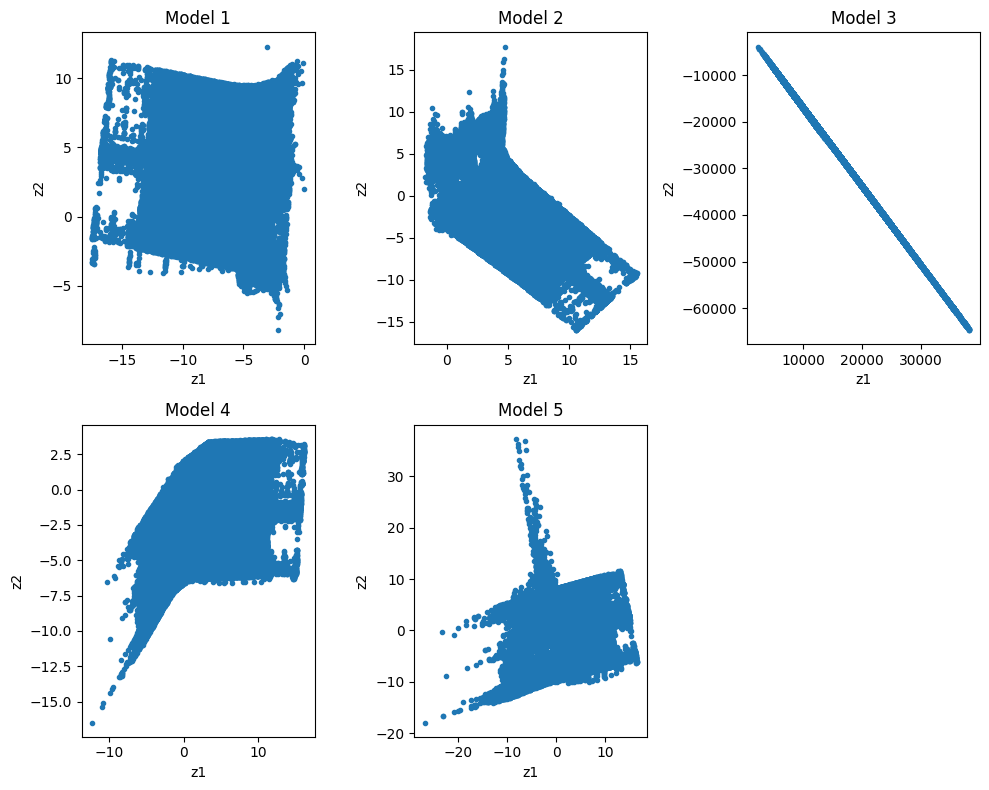

In [10]:
# Show all models' representations in one plot
fig = plt.figure(figsize=(10, 8))
for i, rep in enumerate(reps):
    ax = fig.add_subplot(2, 3, i+1)
    ax.scatter(rep[:,0].cpu().tolist(), rep[:,1].cpu().tolist(), marker='.')
    ax.set_title(f'Model {i+1}')
    ax.set_xlabel('z1')
    ax.set_ylabel('z2')

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from sklearn.mixture import GaussianMixture

def gap_statistic_gmm(X, k_max=10, B=20, random_state=42):
    # Convert torch → numpy if needed
    if hasattr(X, "detach"):
        X = X.detach().cpu().numpy()

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}")

    np.random.seed(random_state)

    n, d = X.shape
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    gaps = np.zeros(k_max)
    sk = np.zeros(k_max)

    for k in range(1, k_max + 1):
        gmm = GaussianMixture(n_components=k, random_state=random_state)
        gmm.fit(X)
        Wk = -gmm.score(X) * n

        Wk_refs = np.zeros(B)

        for b in range(B):
            X_ref = np.random.uniform(
                low=mins,
                high=maxs,
                size=(n, d)
            )
            gmm_ref = GaussianMixture(n_components=k, random_state=random_state)
            gmm_ref.fit(X_ref)
            Wk_refs[b] = -gmm_ref.score(X_ref) * n

        log_Wk_refs = np.log(Wk_refs)
        gaps[k-1] = np.mean(log_Wk_refs) - np.log(Wk)
        sk[k-1] = np.sqrt(1 + 1/B) * np.std(log_Wk_refs)

    return gaps, sk

In [24]:
gaps, sk = gap_statistic_gmm(reps[1], k_max=10)

for k in range(len(gaps) - 1):
    if gaps[k] >= gaps[k + 1] - sk[k + 1]:
        optimal_k = k + 1
        break

print("Optimal k:", optimal_k)

Optimal k: 5


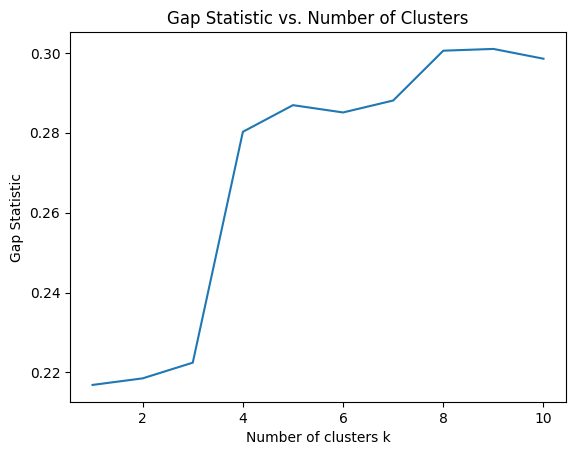

In [25]:
plt.plot(range(1,11),gaps)
plt.xlabel('Number of clusters k')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic vs. Number of Clusters')
plt.show()

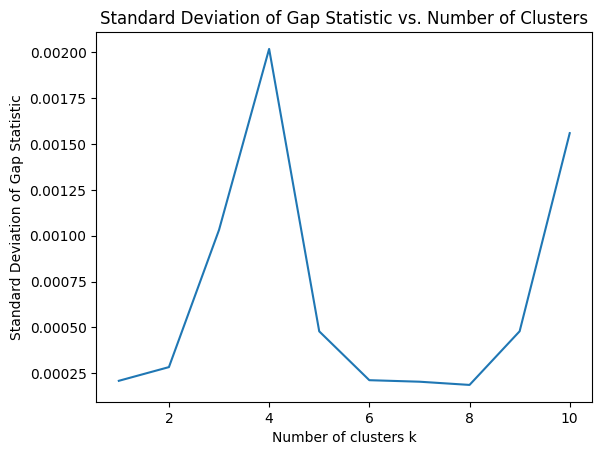

In [26]:
plt.plot(range(1,11),sk)
plt.xlabel('Number of clusters k')
plt.ylabel('Standard Deviation of Gap Statistic')
plt.title('Standard Deviation of Gap Statistic vs. Number of Clusters')
plt.show()

In [17]:
# Use elbow method to find optimal number of clusters for each model
from sklearn.mixture import GaussianMixture 

# Do BIC and AIC calculation for different number of clusters
bic_scores = []
aic_scores = []
ll_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=22)
    gmm.fit(z.cpu().numpy())
    bic_scores.append(gmm.bic(z.cpu().numpy()))
    aic_scores.append(gmm.aic(z.cpu().numpy()))
    ll_scores.append(gmm.score(z.cpu().numpy()))

KeyboardInterrupt: 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# reps is a list of latent matrices, one per model (shape: [N, latent_dim])
n_models = len(reps)
n_components_range = range(1, 12)

# Store scores for all models
all_bic = []

for model_idx, z in enumerate(reps):
    print(f"Evaluating GMM metrics for model {model_idx+1}/{n_models}...")

    z_np = z.cpu().numpy()

    bic_scores = []

    for n_components in n_components_range:
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type='full',
            random_state=22
        )
        gmm.fit(z_np)
        
        # BIC always defined
        bic_scores.append(gmm.bic(z_np))

    all_bic.append(bic_scores)

# Convert to numpy arrays
all_bic = np.array(all_bic)

# ───────────────────────────────────────────────
#                 PLOTTING
# ───────────────────────────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

for i in range(n_models):
    ax_bic = axes[i]
    ax_bic.plot(n_components_range, all_bic[i], marker='o')
    ax_bic.set_title(f"Model {i+1} – BIC")
    ax_bic.set_xlabel("K (clusters)")
    ax_bic.set_ylabel("BIC")

plt.tight_layout()
plt.show()

Evaluating GMM metrics for model 1/5...
Evaluating GMM metrics for model 2/5...
Evaluating GMM metrics for model 3/5...


ValueError: Fitting the mixture model failed because some components have ill-defined empirical covariance (for instance caused by singleton or collapsed samples). Try to decrease the number of components, increase reg_covar, or scale the input data. The numerical accuracy can also be improved by passing float64 data instead of float32.

In [20]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

n_models = len(reps)
n_components_range = range(1, 12)
all_bic = []

for model_idx, z in enumerate(reps):
    print(f"Evaluating GMM metrics for model {model_idx+1}/{n_models}...")

    z_np = z.detach().cpu().numpy().astype(np.float64)

    # Scale latents
    z_np = StandardScaler().fit_transform(z_np)

    bic_scores = []

    for n_components in n_components_range:
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type='full',
            reg_covar=1e-5,
            n_init=5,
            random_state=22
        )

        try:
            gmm.fit(z_np)
            bic_scores.append(gmm.bic(z_np))
        except ValueError:
            bic_scores.append(np.nan)

    all_bic.append(bic_scores)

all_bic = np.array(all_bic)

Evaluating GMM metrics for model 1/5...
Evaluating GMM metrics for model 2/5...
Evaluating GMM metrics for model 3/5...
Evaluating GMM metrics for model 4/5...
Evaluating GMM metrics for model 5/5...


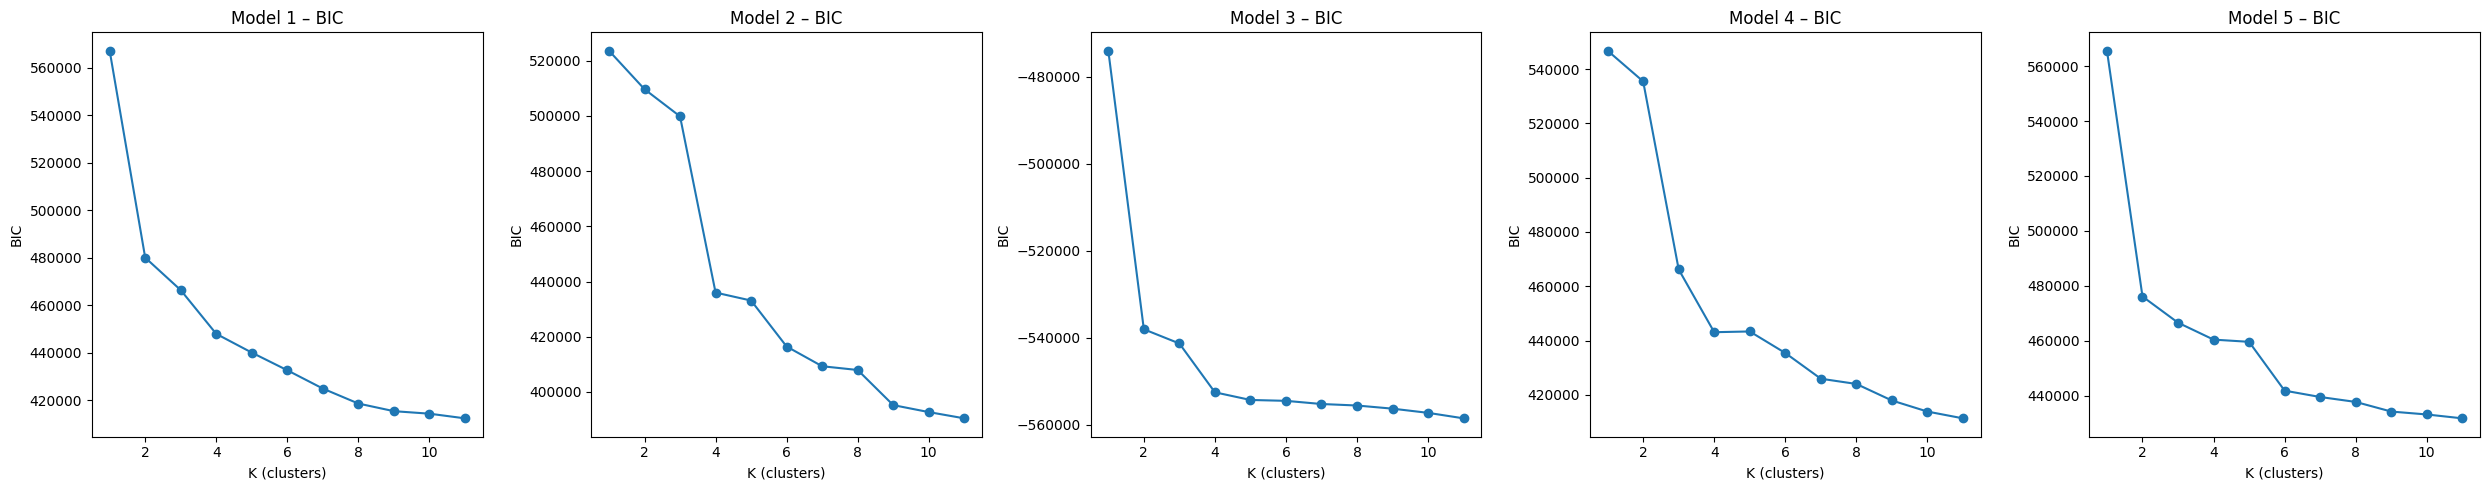

In [21]:
# Plotting
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

for i in range(n_models):
    ax_bic = axes[i]
    ax_bic.plot(n_components_range, all_bic[i], marker='o')
    ax_bic.set_title(f"Model {i+1} – BIC")
    ax_bic.set_xlabel("K (clusters)")
    ax_bic.set_ylabel("BIC")

plt.tight_layout()
plt.show()

Evaluating GMM metrics for model 1/5...
Evaluating GMM metrics for model 2/5...
Evaluating GMM metrics for model 3/5...
Evaluating GMM metrics for model 4/5...
Evaluating GMM metrics for model 5/5...


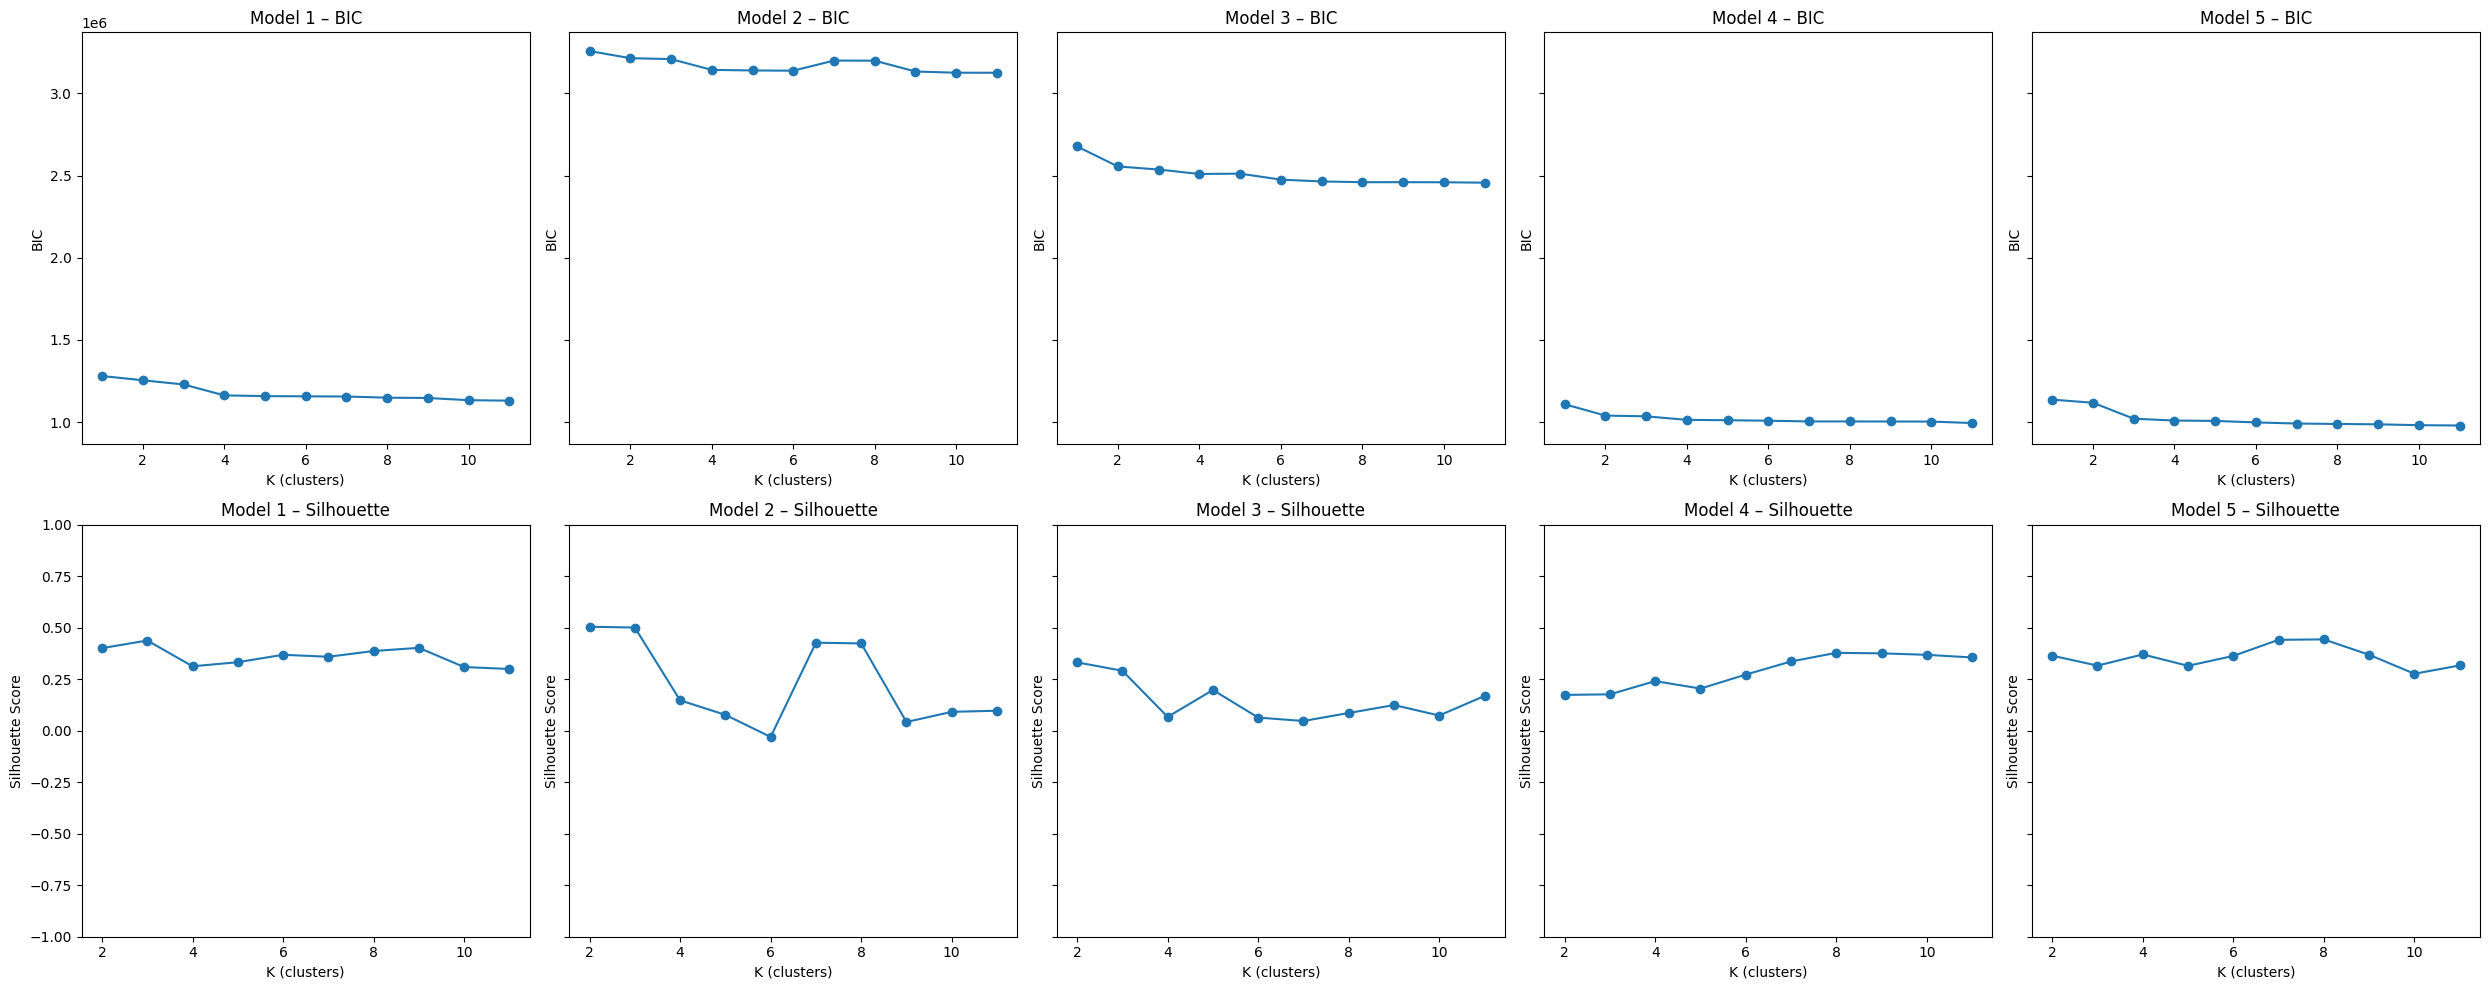

In [66]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_score

# # reps is a list of latent matrices, one per model (shape: [N, latent_dim])
# n_models = len(reps)
# n_components_range = range(1, 12)

# # Store scores for all models
# all_bic = []
# all_silhouette = []

# for model_idx, z in enumerate(reps):
#     print(f"Evaluating GMM metrics for model {model_idx+1}/{n_models}...")

#     z_np = z.cpu().numpy()

#     bic_scores = []
#     silhouette_scores = []

#     for n_components in n_components_range:
#         gmm = GaussianMixture(
#             n_components=n_components,
#             covariance_type='full',
#             random_state=22
#         )
#         gmm.fit(z_np)
        
#         # BIC always defined
#         bic_scores.append(gmm.bic(z_np))

#         # Silhouette only valid if n_components > 1
#         if n_components > 1:
#             labels = gmm.predict(z_np)
#             sil = silhouette_score(z_np, labels)
#             silhouette_scores.append(sil)
#         else:
#             silhouette_scores.append(np.nan)

#     all_bic.append(bic_scores)
#     all_silhouette.append(silhouette_scores)

# # Convert to numpy arrays
# all_bic = np.array(all_bic)
# all_silhouette = np.array(all_silhouette)

# # ───────────────────────────────────────────────
# #                 PLOTTING
# # ───────────────────────────────────────────────
# fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 10))

# if n_models == 1:
#     axes = np.array([[axes[0]], [axes[1]]])

# for i in range(n_models):

#     # --- Top Row: BIC ---
#     ax_bic = axes[0, i]
#     ax_bic.plot(n_components_range, all_bic[i], marker='o')
#     ax_bic.set_title(f"Model {i+1} – BIC")
#     ax_bic.set_xlabel("K (clusters)")
#     ax_bic.set_ylabel("BIC")

#     # --- Bottom Row: Silhouette ---
#     ax_sil = axes[1, i]
#     ax_sil.plot(n_components_range, all_silhouette[i], marker='o')
#     ax_sil.set_title(f"Model {i+1} – Silhouette")
#     ax_sil.set_xlabel("K (clusters)")
#     ax_sil.set_ylabel("Silhouette Score")
#     ax_sil.set_ylim(-1, 1)

# plt.tight_layout()
# plt.show()

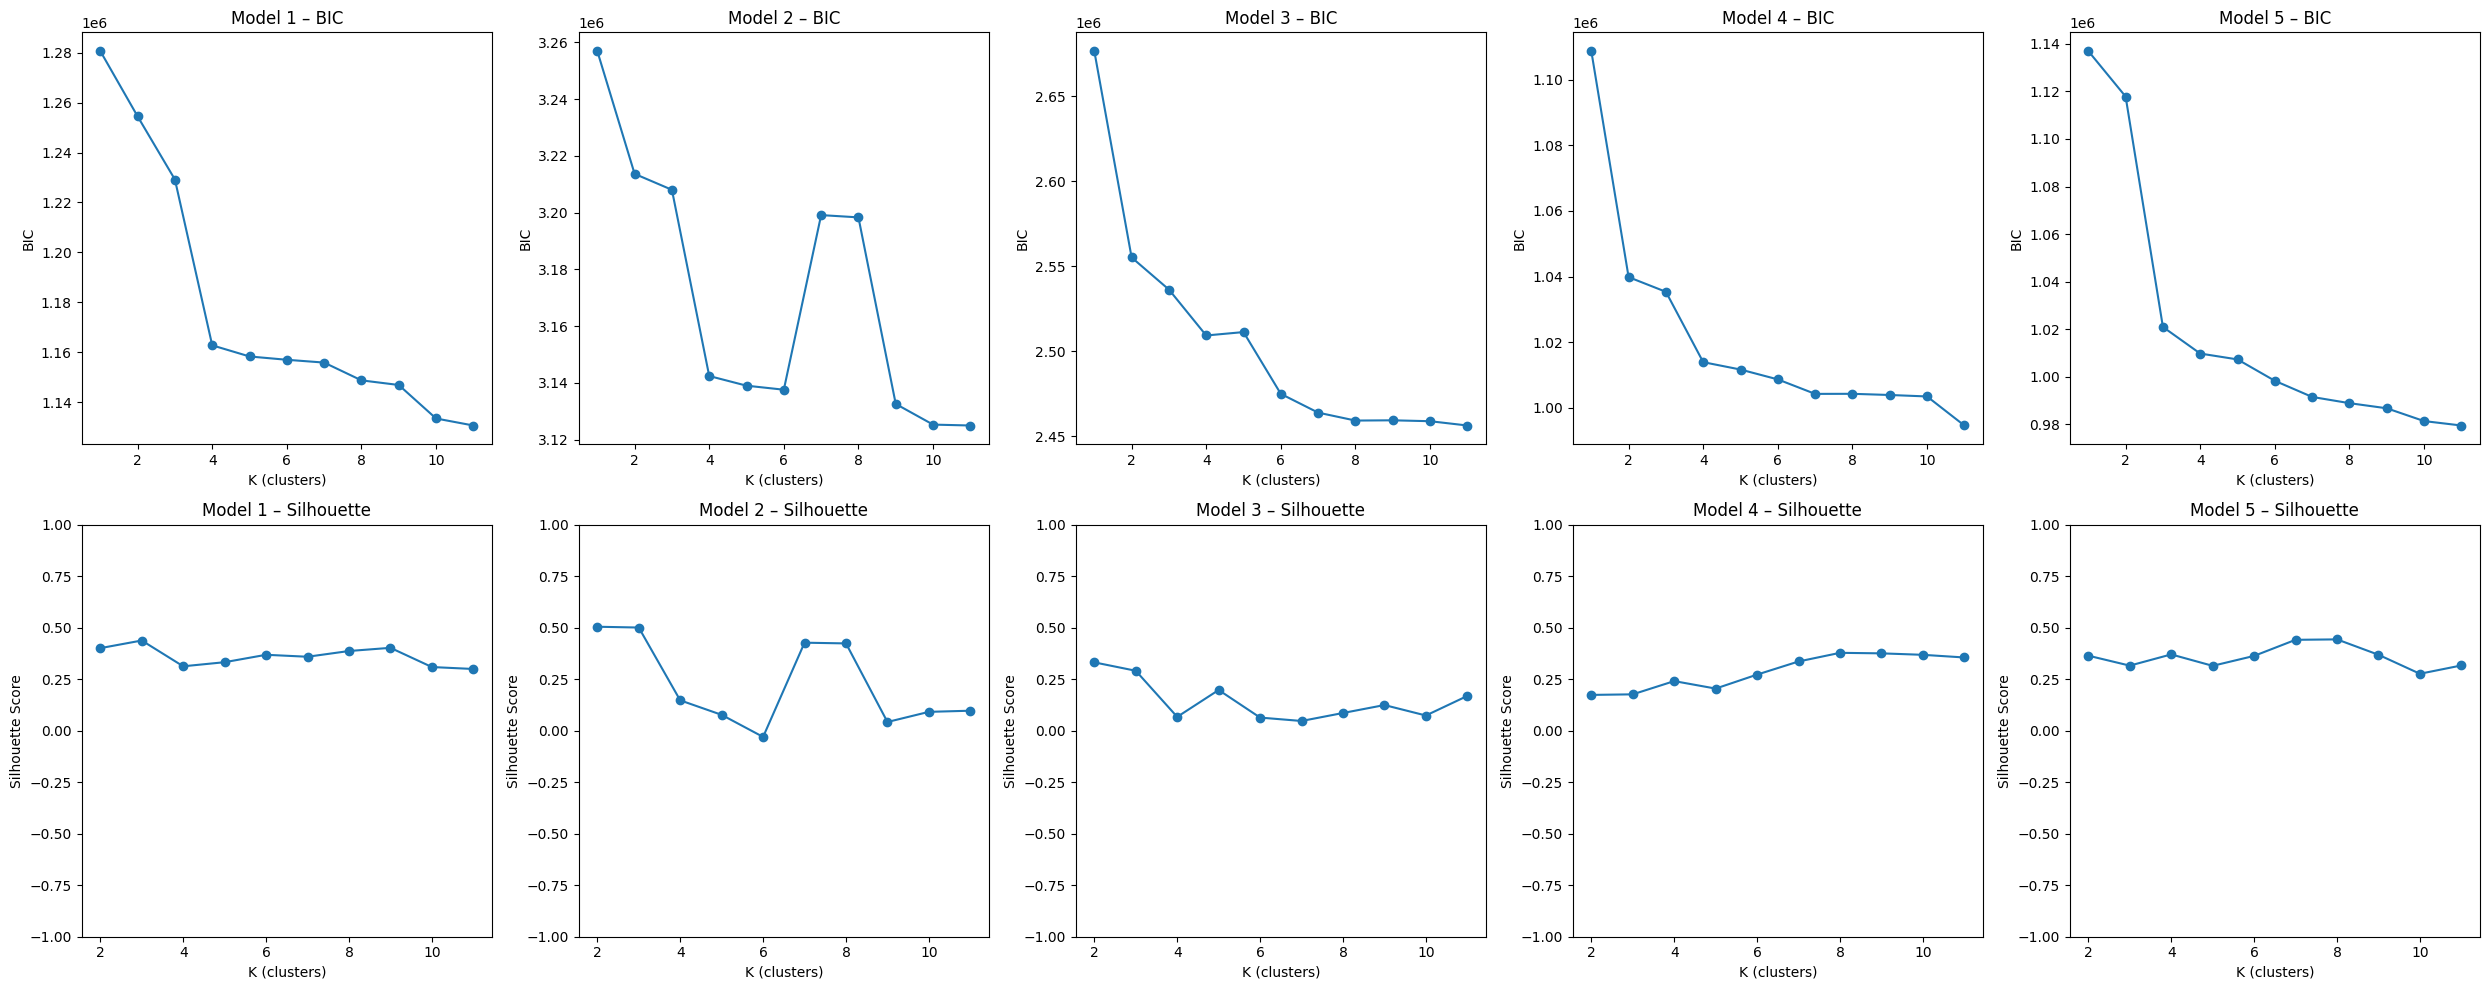

In [67]:
fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 10))

if n_models == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i in range(n_models):

    # --- Top Row: BIC ---
    ax_bic = axes[0, i]
    ax_bic.plot(n_components_range, all_bic[i], marker='o')
    ax_bic.set_title(f"Model {i+1} – BIC")
    ax_bic.set_xlabel("K (clusters)")
    ax_bic.set_ylabel("BIC")

    # --- Bottom Row: Silhouette ---
    ax_sil = axes[1, i]
    ax_sil.plot(n_components_range, all_silhouette[i], marker='o')
    ax_sil.set_title(f"Model {i+1} – Silhouette")
    ax_sil.set_xlabel("K (clusters)")
    ax_sil.set_ylabel("Silhouette Score")
    ax_sil.set_ylim(-1, 1)

plt.tight_layout()
plt.show()